In [75]:
!git clone https://github.com/egeozgul/SLAM_3D_Reconstruction /tmp/slam_repo
!cp -r /tmp/slam_repo/. .
!rm -rf /tmp/slam_repo

Cloning into '/tmp/slam_repo'...
remote: Enumerating objects: 203, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 203 (delta 36), reused 8 (delta 3), pack-reused 139 (from 3)
Receiving objects: 100% (203/203), 102.97 MiB | 16.89 MiB/s, done.
Resolving deltas: 100% (37/37), done.


In [76]:
!pip install plotly
!pip install plyfile
!pip install open3d

In [77]:
import open3d as o3d
import numpy as np
import cv2
from scipy.optimize import least_squares
import os
import open3d as o3d
import copy
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from plyfile import PlyData, PlyElement
import plotly.graph_objects as go

fig = go.Figure()

## Find Features with SIFT and Lowe's Filter

In this step, we use the **SIFT (Scale-Invariant Feature Transform)** algorithm to detect features in images. Following that, we employ a **Brute-Force KNN Matcher** with Lowe's filter to identify strong matches between the detected features.


In [78]:
def find_features(img0, img1):
    """
    Detect keypoints and compute descriptors for two images using the SIFT algorithm.

    Parameters:
    - img0: First input image.
    - img1: Second input image.

    Returns:
    - pts0: Keypoints in the first image.
    - pts1: Keypoints in the second image.
    """
    # Convert images to grayscale
    img0gray = cv2.cvtColor(img0, cv2.COLOR_BGR2GRAY)
    img1gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

    # Initialize SIFT detector
    sift = cv2.SIFT_create()

    # Detect keypoints and compute descriptors for both images
    kp0, des0 = sift.detectAndCompute(img0gray, None)
    kp1, des1 = sift.detectAndCompute(img1gray, None)

    # Use Brute-Force Matcher for descriptor matching
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des0, des1, k=2)

    # Apply ratio test to find good matches
    good = []
    for m, n in matches:
        if m.distance < 0.70 * n.distance:
            good.append(m)

    # Extract coordinates of keypoints from good matches
    pts0 = np.float32([kp0[m.queryIdx].pt for m in good])
    pts1 = np.float32([kp1[m.trainIdx].pt for m in good])
    return pts0, pts1

## Data Association for 3D Reconstruction

This code performs data association between initial points (pts1) and new points (pts2 and pts3). The primary goal is to find common points between two sets of points from different images.


In [79]:
def data_association(pts1, pts2, pts3):
    """
    Perform data association between initial points and new points.

    Find common points between two sets of points (pts1 and pts2) and a third set (pts3).

    Parameters:
    - pts1: Points from the first image.
    - pts2: Points from the second image.
    - pts3: Points from the third image.

    Returns:
    - common_indices_1: Indices of common points in pts1.
    - common_indices_2: Indices of common points in pts2.
    - unmatched_pts2: Points in pts2 that are not common.
    - unmatched_pts3: Points in pts3 that are not common.
    """
    if pts1.shape[0] == 0 or pts2.shape[0] == 0 or pts3.shape[0] == 0:
        print("One or more sets of points are empty.")
        return None, None, None, None

    common_indices_1 = []
    common_indices_2 = []

    # Iterate through points in pts1
    for i in range(pts1.shape[0]):
        matching_indices = np.where((pts2 == pts1[i, :]).all(axis=1))
        # If a match is found in pts2
        if matching_indices[0].size > 0:
            common_indices_1.append(i)
            common_indices_2.append(matching_indices[0][0])

    if not common_indices_1 or not common_indices_2:
        print("No common points found.")
        return None, None, None, None

    # Create masked arrays to filter out common points
    unmatched_pts2 = np.ma.array(pts2, mask=False)
    unmatched_pts2.mask[common_indices_2] = True
    unmatched_pts2 = unmatched_pts2.compressed()
    unmatched_pts2 = unmatched_pts2.reshape(int(unmatched_pts2.shape[0] / 2), 2)

    unmatched_pts3 = np.ma.array(pts3, mask=False)
    unmatched_pts3.mask[common_indices_2] = True
    unmatched_pts3 = unmatched_pts3.compressed()
    unmatched_pts3 = unmatched_pts3.reshape(int(unmatched_pts3.shape[0] / 2), 2)

    return np.array(common_indices_1), np.array(common_indices_2), unmatched_pts2, unmatched_pts3

## Triangulation for 3D Reconstruction

This function performs triangulation to reconstruct 3D points from corresponding 2D points in two images.


In [80]:
def Triangulation(P1, P2, pts1, pts2):
    """
    Perform triangulation to reconstruct 3D points from corresponding 2D points in two images.

    Parameters:
    - P1: Projection matrix for the first camera.
    - P2: Projection matrix for the second camera.
    - pts1: 2D points in the first image.
    - pts2: 2D points in the second image.

    Returns:
    - points1: Transposed 2D points in the first image.
    - points2: Transposed 2D points in the second image.
    - cloud: Triangulated 3D points.
    """
    # Transpose 2D point arrays to get input data in the expected format for cv2.triangulatePoints
    points1 = np.transpose(pts1)
    points2 = np.transpose(pts2)

    # Perform triangulation to obtain homogeneous 3D coordinates
    cloud = cv2.triangulatePoints(P1, P2, points1, points2)

    # Convert homogeneous coordinates to non-homogeneous coordinates
    cloud = cloud / cloud[3]

    return points1, points2, cloud

## Perspective-n-Point (PnP) Pose Estimation

This function estimates the camera pose using the Perspective-n-Point (PnP) algorithm, specifically using `cv2.solvePnPRansac`.


In [81]:
def PnP(world_points, image_points, intrinsic_matrix, distortion_coefficients, original_image_points, initial):
    """
    Estimate camera pose using solvePnPRansac.

    Parameters:
    - world_points: 3D coordinates of world points.
    - image_points: 2D coordinates of corresponding image points.
    - intrinsic_matrix: Intrinsic camera matrix.
    - distortion_coefficients: Distortion coefficients.
    - original_image_points: Original 2D image points.
    - initial: Flag indicating whether the function is used in the initial stage.

    Returns:
    - rotation_matrix: Rotation matrix.
    - translation_vector: Translation vector.
    - filtered_image_points: Filtered 2D image points.
    - filtered_world_points: Filtered 3D world points.
    - filtered_original_image_points: Filtered original 2D image points.
    """
    # Check if the function is used in the initial stage
    if initial == 1:
        # If initial, reshape the input arrays for consistency
        world_points = world_points[:, 0, :]  # to remove empty dimension
        image_points = image_points.T
        original_image_points = original_image_points.T

    # Check if there are enough 3D points for PnP
    if len(world_points) < 4:
        print("Not enough points for PnP.")
        return None, None, None, world_points, original_image_points

    # Use solvePnPRansac to estimate the pose (R, t) from 3D-2D correspondences
    ret, rotation_vector, translation_vector, inliers = cv2.solvePnPRansac(
        world_points, image_points, intrinsic_matrix, distortion_coefficients, cv2.SOLVEPNP_ITERATIVE
    )

    # Check if the PnP solution is successful
    if ret is not None:
        # Convert rotation vector to rotation matrix
        rotation_matrix, _ = cv2.Rodrigues(rotation_vector)

        # If inliers are obtained, filter the input arrays accordingly
        if inliers is not None:
            image_points = image_points[inliers[:, 0]]
            world_points = world_points[inliers[:, 0]]
            original_image_points = original_image_points[inliers[:, 0]]

        # Return the rotation matrix (R), translation vector (t), filtered 2D points (image_points),
        # filtered 3D points (world_points), and filtered original 2D points (original_image_points)
        return rotation_matrix, translation_vector, image_points, world_points, original_image_points
    else:
        print("PnP failed to find a solution.")
        # If PnP fails, return None for rotation matrix, translation vector, and filtered arrays
        return None, None, None, world_points, original_image_points

## Reprojection Error for optimization

This function computes the reprojection error of 3D world points onto 2D image points, providing a metric for the accuracy of the camera pose.


In [82]:
def compute_reprojection_error(world_points, image_points, camera_pose, intrinsic_matrix, homogeneity):
    """
    Compute the reprojection error of 3D world points onto 2D image points.

    Parameters:
    - world_points: 3D coordinates of world points.
    - image_points: 2D coordinates of corresponding image points.
    - camera_pose: Camera pose matrix (extrinsic parameters).
    - intrinsic_matrix: Intrinsic camera matrix.
    - homogeneity: Flag indicating whether to use homogeneous coordinates.

    Returns:
    - total_error: Total reprojection error.
    - transformed_world_points: Transformed world points.
    - projected_points: Projected points on the image.
    """
    total_error = 0

    # Extract rotation and translation from the camera pose matrix
    rotation_matrix = camera_pose[:3, :3]
    translation_vector = camera_pose[:3, 3]

    # Convert rotation matrix to Rodrigues representation
    rvec, _ = cv2.Rodrigues(rotation_matrix)

    # Convert 3D world points to homogeneous coordinates if required
    if homogeneity == 1:
        world_points = cv2.convertPointsFromHomogeneous(world_points.T)

    # Project 3D world points onto the 2D image plane
    projected_points, _ = cv2.projectPoints(world_points, rvec, translation_vector, intrinsic_matrix, distCoeffs=None)
    projected_points = projected_points[:, 0, :]
    projected_points = np.float32(projected_points)

    # Compute reprojection error
    if homogeneity == 1:
        total_error = cv2.norm(projected_points, image_points.T, cv2.NORM_L2)
    else:
        total_error = cv2.norm(projected_points, image_points, cv2.NORM_L2)

    # Transpose image_points for further processing
    image_points = image_points.T

    # Normalize total error by the number of points
    normalized_error = total_error / len(projected_points)

    return normalized_error, world_points, projected_points


## Bundle Adjustment

This function performs bundle adjustment to optimize the parameters, including projection matrix, intrinsic matrix, image points, and 3D world points.


In [83]:
#  https://scipy-cookbook.readthedocs.io/items/bundle_adjustment.html

def calculate_optimization_reprojection_error(params):
    # Extracting parameters
    projection_matrix = params[0:12].reshape((3, 4))
    intrinsic_matrix = params[12:21].reshape((3, 3))

    # Extracting image points
    num_image_points = len(params[21:])
    num_image_points_to_use = int(num_image_points * 0.4)
    image_points = params[21:21 + num_image_points_to_use].reshape((2, int(num_image_points_to_use / 2)))

    # Extracting 3D points
    num_3d_points = int(len(params[21 + num_image_points_to_use:]) / 3)
    three_d_points = params[21 + num_image_points_to_use:].reshape((num_3d_points, 3))

    # Extracting rotation and translation
    rotation_matrix = projection_matrix[:3, :3]
    translation_vector = projection_matrix[:3, 3]

    image_points = image_points.T
    num_points = len(image_points)
    error = []

    rotation_vector, _ = cv2.Rodrigues(rotation_matrix)

    projected_2d_points, _ = cv2.projectPoints(three_d_points, rotation_vector, translation_vector, intrinsic_matrix, distCoeffs=None)
    projected_2d_points = projected_2d_points[:, 0, :]

    for idx in range(num_points):
        actual_image_point = image_points[idx]
        reprojected_image_point = projected_2d_points[idx]
        point_error = (actual_image_point - reprojected_image_point) ** 2
        error.append(point_error)

    error_array = np.array(error).ravel() / num_points

    return error_array

def bundle_adjustment(points_3d, image_points, projection_matrix, intrinsic_matrix, reprojection_error_threshold):
    # Concatenate parameters for optimization
    optimization_variables = np.hstack((projection_matrix.ravel(), intrinsic_matrix.ravel()))
    optimization_variables = np.hstack((optimization_variables, image_points.ravel()))
    optimization_variables = np.hstack((optimization_variables, points_3d.ravel()))

    # Calculate initial error
    initial_error = np.sum(calculate_optimization_reprojection_error(optimization_variables))

    # Use least squares optimization to minimize reprojection error
    optimized_values = least_squares(fun=calculate_optimization_reprojection_error, x0=optimization_variables, gtol=reprojection_error_threshold)

    # Extract optimized values
    optimized_values = optimized_values.x
    optimized_projection_matrix = optimized_values[:12].reshape((3, 4))

    remaining_elements = len(optimized_values[21:])
    num_image_points = int(remaining_elements * 0.4)
    optimized_image_points = optimized_values[21:21 + num_image_points].reshape((2, num_image_points // 2)).T

    optimized_world_coordinates = optimized_values[21 + num_image_points:].reshape((int(remaining_elements / 3), 3))
    optimized_image_points = optimized_image_points.T

    return optimized_world_coordinates, optimized_image_points, optimized_projection_matrix

In [84]:
def draw_points(image, pts, repro):
    if repro == False:
        image = cv2.drawKeypoints(image, pts, image, color=(0, 255, 0), flags=0)
    else:
        for p in pts:
            image = cv2.circle(image, tuple(p), 2, (0, 0, 255), -1)
    return image

In [85]:
def create_pointcloud(output_path, point_cloud, colors):
    """
    Convert 3D point cloud data to PLY format and save it to a file.

    Parameters:
    - output_path: Path to the directory where the PLY file will be saved.
    - point_cloud: 3D point cloud data (numpy array).
    - colors: RGB colors corresponding to each point in the cloud.

    Returns:
    None
    """
    # Rescale point cloud coordinates and concatenate with colors
    scaled_points = point_cloud.reshape(-1, 3) * 200
    colored_points = np.hstack([scaled_points, colors.reshape(-1, 3)])

    # Clean the point cloud by removing points outside a certain distance from the mean
    mean_point = np.mean(colored_points[:, :3], axis=0)
    centered_points = colored_points[:, :3] - mean_point
    distances = np.sqrt(centered_points[:, 0] ** 2 + centered_points[:, 1] ** 2 + centered_points[:, 2] ** 2)
    valid_indices = np.where(distances < np.mean(distances) + 300)
    cleaned_points = colored_points[valid_indices]

    # Define PLY header
    ply_header = '''ply
        format ascii 1.0
        element vertex %(num_verts)d
        property float x
        property float y
        property float z
        property uchar blue
        property uchar green
        property uchar red
        end_header
        '''

    # Write the PLY file
    with open(os.path.join(output_path, "Point_Cloud", "sparse_ptcloud1.ply"), "w") as file:
        file.write(ply_header % dict(num_verts=len(cleaned_points)))
        np.savetxt(file, cleaned_points, '%f %f %f %d %d %d')


## SFM pipeline
The SFM Pipeline is designed to perform incremental Structure from Motion (SFM) for multiple images

In [86]:
def sfm_pipeline(path, img_dir, intrinsic_matrix, perform_bundle_adjustment=False):
    image_dataset = os.path.basename(img_dir)

    # ── Initialisation ────────────────────────────────────────────────────────
    # Flatten the intrinsic (camera calibration) matrix into a 1-D array that
    # will accumulate all camera poses for later export.
    print("Initialized Initial Parameters")
    pose_array = intrinsic_matrix.ravel()

    # The first camera is fixed at the world origin (identity rotation, zero
    # translation).  All other poses will be expressed relative to this one.
    initial_pose_matrix = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0]])
    current_pose_matrix = np.empty((3, 4))

    # Projection matrix P = K · [R | t].  For the first camera this is simply K
    # times the identity extrinsic matrix defined above.
    projection_matrix_1 = np.matmul(intrinsic_matrix, initial_pose_matrix)
    reference_projection_matrix = projection_matrix_1
    projection_matrix_2 = np.empty((3, 4))

    # Accumulators for the full point cloud (3-D positions + BGR colours).
    total_points_3d = np.zeros((1, 3))
    total_colors = np.zeros((1, 3))
    images = []

    # Collect all JPEG / PNG filenames from the image directory in sorted order
    # so that consecutive entries correspond to consecutive video frames.
    for img_filename in sorted(os.listdir(img_dir)):
        if '.jpg' in img_filename.lower() or '.png' in img_filename.lower():
            images += [img_filename]

    i = 0
    mesh = o3d.geometry.TriangleMesh.create_coordinate_frame()

    # ── Bootstrap: initialise the reconstruction from the first image pair ────
    image_0 = cv2.imread(os.path.join(img_dir, images[i]))
    image_1 = cv2.imread(os.path.join(img_dir, images[i + 1]))

    # Detect and match keypoint pairs between the first two images.
    pts0, pts1 = find_features(image_0, image_1)

    # Estimate the Essential Matrix (encodes the relative rotation and
    # translation between two calibrated cameras) using RANSAC to reject
    # outlier correspondences.
    essential_matrix, mask = cv2.findEssentialMat(pts0, pts1, intrinsic_matrix, method=cv2.RANSAC, prob=0.999, threshold=0.4, mask=None)

    # Keep only the inlier matches that RANSAC deemed geometrically consistent.
    pts0 = pts0[mask.ravel() == 1]
    pts1 = pts1[mask.ravel() == 1]

    # Decompose the Essential Matrix into rotation (R) and translation (t),
    # choosing the solution where the most points lie in front of both cameras.
    _, rotation_matrix, translation, mask = cv2.recoverPose(essential_matrix, pts0, pts1, intrinsic_matrix)
    pts0 = pts0[mask.ravel() > 0]
    pts1 = pts1[mask.ravel() > 0]

    # Build the extrinsic matrix for the second camera by chaining the recovered
    # rotation and translation onto the first camera's pose.
    current_pose_matrix[:3, :3] = np.matmul(rotation_matrix, initial_pose_matrix[:3, :3])
    current_pose_matrix[:3, 3] = initial_pose_matrix[:3, 3] + np.matmul(initial_pose_matrix[:3, :3], translation.ravel())
    projection_matrix_2 = np.matmul(intrinsic_matrix, current_pose_matrix)

    # Triangulate the inlier correspondences to get an initial set of 3-D points.
    pts0, pts1, points_3d = Triangulation(projection_matrix_1, projection_matrix_2, pts0, pts1)

    # Measure how accurately the triangulated points re-project onto image 2.
    reprojection_error, points_3d, reprojection_points = compute_reprojection_error(points_3d, pts1, current_pose_matrix, intrinsic_matrix, homogeneity=1)
    print("REPROJECTION ERROR: ", reprojection_error)

    # Run Perspective-n-Point (PnP) on the first pair to refine correspondences
    # used as the seed for the incremental loop below.
    rotation, translation, pts1, points_3d, keypoints_0_transformed = PnP(points_3d, pts1, intrinsic_matrix, np.zeros((5, 1), dtype=np.float32), pts0, initial=1)

    # Reset rotation/translation – the first camera stays at the world origin.
    rotation = np.eye(3)
    translation = np.array([[0], [0], [0]], dtype=np.float32)

    total_images = len(images) - 2  # number of remaining images to process

    # Append the two bootstrap projection matrices to the pose log.
    pose_array = np.hstack((pose_array, projection_matrix_1.ravel()))
    pose_array = np.hstack((pose_array, projection_matrix_2.ravel()))

    # Threshold used to decide when the bundle-adjustment optimiser has converged.
    gradient_threshold = 0.4

    # ── Incremental loop: register each new image into the reconstruction ──────
    for image_index in tqdm(range(total_images)):

        # Load the next image in the sequence.
        current_image = cv2.imread(os.path.join(img_dir, images[image_index + 2]))

        # Find feature matches between the previous image and the new one.
        pts_, pts2 = find_features(image_1, current_image)

        # For every image after the second, triangulate new 3-D points from the
        # previous camera pair before attempting to localise the new camera.
        if image_index != 0:
            pts0, pts1, points_3d = Triangulation(projection_matrix_1, projection_matrix_2, pts0, pts1)
            pts1 = pts1.T
            points_3d = cv2.convertPointsFromHomogeneous(points_3d.T)
            points_3d = points_3d[:, 0, :]

        # Identify 2-D keypoints in the previous image that appear in both
        # the existing point cloud and the new image (data association).
        indices_1, indices_2, temp_keypoints_current, temp_keypoints_new = data_association(pts1, pts_, pts2)
        common_keypoints_current_image = pts2[indices_2]
        common_keypoints_previous = pts_[indices_2]

        # Use PnP to estimate the new camera's pose from the known 3-D points
        # matched to 2-D observations in the new image.
        rotation, translation, common_keypoints_current_image, points_3d, common_keypoints_previous = PnP(points_3d[indices_1], common_keypoints_current_image, intrinsic_matrix, np.zeros((5, 1), dtype=np.float32), common_keypoints_previous, initial=0)

        # Assemble the full 3×4 extrinsic and projection matrices for the new camera.
        new_extrinsic_matrix = np.hstack((rotation, translation))
        new_projection_matrix = np.matmul(intrinsic_matrix, new_extrinsic_matrix)

        # Evaluate reprojection error for the PnP-registered points.
        error, points_3d, _ = compute_reprojection_error(points_3d, common_keypoints_current_image, new_extrinsic_matrix, intrinsic_matrix, homogeneity=0)

        # Triangulate additional 3-D points from keypoints that are new (not yet
        # in the point cloud) using the previous and new camera pair.
        temp_keypoints_previous, temp_keypoints_current, points_3d = Triangulation(projection_matrix_2, new_projection_matrix, temp_keypoints_current, temp_keypoints_new)

        # Check reprojection quality for the freshly triangulated points.
        error, points_3d, _ = compute_reprojection_error(points_3d, temp_keypoints_current, new_extrinsic_matrix, intrinsic_matrix, homogeneity=1)
        print("Reprojection Error: ", error)

        # Log the new camera's projection matrix.
        pose_array = np.hstack((pose_array, new_projection_matrix.ravel()))

        # ── Optional bundle adjustment ─────────────────────────────────────────
        if perform_bundle_adjustment:
            # Jointly optimise 3-D point positions and camera parameters to
            # minimise the total reprojection error across all observations.
            print("Bundle Adjustment...")
            points_3d, temp_keypoints_current, new_projection_matrix = bundle_adjustment(points_3d, temp_keypoints_current, new_projection_matrix, intrinsic_matrix, gradient_threshold)
            new_projection_matrix = np.matmul(intrinsic_matrix, new_projection_matrix)
            error, points_3d, _ = compute_reprojection_error(points_3d, temp_keypoints_current, new_extrinsic_matrix, intrinsic_matrix, homogeneity=0)
            print("Minimized error: ", error)

            # Add the refined points and their colours to the global cloud.
            total_points_3d = np.vstack((total_points_3d, points_3d))
            keypoints_current_reg = np.array(temp_keypoints_current, dtype=np.int32)
            colors = np.array([current_image[l[1], l[0]] for l in keypoints_current_reg])
            total_colors = np.vstack((total_colors, colors))
        else:
            # Without bundle adjustment, directly append the new points.
            total_points_3d = np.vstack((total_points_3d, points_3d[:, 0, :]))
            keypoints_current_reg = np.array(temp_keypoints_current, dtype=np.int32)
            # Sample the pixel colour at each keypoint location to colour the cloud.
            colors = np.array([current_image[l[1], l[0]] for l in keypoints_current_reg.T])
            total_colors = np.vstack((total_colors, colors))

        # ── Slide the window forward: the current camera becomes the new "previous" ──
        projection_matrix_1 = np.copy(projection_matrix_2)
        image_0 = np.copy(image_1)
        image_1 = np.copy(current_image)
        pts0 = np.copy(pts_)
        pts1 = np.copy(pts2)
        projection_matrix_2 = np.copy(new_projection_matrix)

    # ── Export ────────────────────────────────────────────────────────────────
    # Write the accumulated point cloud (positions + colours) to disk.
    print("Processing Point Cloud...")
    create_pointcloud(path, total_points_3d, total_colors)
    print(f"Incremental SFM for {image_dataset} dataset completed!")

    return pose_array

## Execution of the above pipeline

- Input the Intrinsic Camera Matrx
- Input opath for the dataset containing .jpg or .png images


In [87]:

# Input Camera Intrinsic Parameters
K = np.array([[2393.952166119461, -3.410605131648481e-13, 932.3821770809047],
              [0, 2398.118540286656, 628.2649953288065],
              [0, 0, 1]])

#create Point_Cloud folder if it doesnt exist already
os.makedirs('/content/Point_Cloud', exist_ok=True)

# Other parameters
bundle_adjustment = False
path = os.getcwd()
img_dir = os.path.join(path, 'kizkulesi')

pose_array = sfm_pipeline(path, img_dir, K, bundle_adjustment)

Initialized Initial Parameters
REPROJECTION ERROR:  0.005625768623491871


  4%|▍         | 1/23 [00:00<00:21,  1.05it/s]

Reprojection Error:  0.524833142400175


  9%|▊         | 2/23 [00:01<00:19,  1.07it/s]

Reprojection Error:  1.7934438678781917


...

Reprojection Error:  1.0199553802676422


 96%|█████████▌| 22/23 [00:20<00:00,  1.13it/s]

Reprojection Error:  0.44319407038153424


100%|██████████| 23/23 [00:21<00:00,  1.06it/s]

Reprojection Error:  1.4011352446650893
Processing Point Cloud...
Incremental SFM for kizkulesi dataset completed!


### Transforming and filtering the 3d point cloud of the 3d Reconstruction

In [88]:
# Fix the malformed header by stripping leading whitespace
with open("./Point_Cloud/sparse_ptcloud1.ply", "r") as f:
    content = f.read()

fixed = "\n".join(line.strip() for line in content.splitlines())

with open("./Point_Cloud/sparse_ptcloud1.ply", "w") as f:
    f.write(fixed)

In [89]:
plydata = PlyData.read("./Point_Cloud/sparse_ptcloud1.ply")
v = plydata['vertex']
points = np.column_stack([v['x'], v['y'], v['z']])
colors = np.column_stack([v['red'], v['green'], v['blue']])

# ---- Set rotation angles here ----
rx = 230  # degrees around X axis
ry = 0    # degrees around Y axis
rz = 45   # degrees around Z axis
# ---- Set clip ranges here --------
x_min, x_max = -150,100
y_min, y_max = -150,150
z_min, z_max = 600, 800
# ----------------------------------

def Rx(a):
    a = np.radians(a)
    return np.array([[1,0,0],[0,np.cos(a),-np.sin(a)],[0,np.sin(a),np.cos(a)]])

def Ry(a):
    a = np.radians(a)
    return np.array([[np.cos(a),0,np.sin(a)],[0,1,0],[-np.sin(a),0,np.cos(a)]])

def Rz(a):
    a = np.radians(a)
    return np.array([[np.cos(a),-np.sin(a),0],[np.sin(a),np.cos(a),0],[0,0,1]])

# Rotate around centroid
centroid = points.mean(axis=0)
centered = points - centroid
R = Rz(rz) @ Ry(ry) @ Rx(rx)
rotated = (R @ centered.T).T + centroid

# Keep only points within all axis ranges
mask = (
    (rotated[:, 0] >= x_min) & (rotated[:, 0] <= x_max) &
    (rotated[:, 1] >= y_min) & (rotated[:, 1] <= y_max) &
    (rotated[:, 2] >= z_min) & (rotated[:, 2] <= z_max)
)
rotated = rotated[mask]
rgb = [f'rgb({r},{g},{b})' for r, g, b in colors[mask]]

# Build structured array for PLY
vertex_data = np.zeros(len(rotated), dtype=[
    ('x', 'f4'), ('y', 'f4'), ('z', 'f4'),
    ('red', 'u1'), ('green', 'u1'), ('blue', 'u1')
])

vertex_data['x'] = rotated[:, 0]
vertex_data['y'] = rotated[:, 1]
vertex_data['z'] = rotated[:, 2]
vertex_data['red']   = colors[mask][:, 0]
vertex_data['green'] = colors[mask][:, 1]
vertex_data['blue']  = colors[mask][:, 2]

el = PlyElement.describe(vertex_data, 'vertex')
PlyData([el]).write('./Point_Cloud/sparse_ptcloud_rotated.ply')

print("Saved to ./Point_Cloud/sparse_ptcloud_rotated.ply")

Saved to ./Point_Cloud/sparse_ptcloud_rotated.ply


# Displaying the pointcloud in interactive viewer

In [90]:
import plotly.graph_objects as go

plydata = PlyData.read("./Point_Cloud/sparse_ptcloud_rotated.ply")
v = plydata['vertex']
points = np.column_stack([v['x'], v['y'], v['z']])
colors = np.column_stack([v['red'], v['green'], v['blue']])

fig = go.Figure(data=[go.Scatter3d(
    x=rotated[:, 0],
    y=rotated[:, 1],
    z=rotated[:, 2],
    mode='markers',
    marker=dict(size=1.5, color=rgb, opacity=0.8)
)])

fig.update_layout(
    title=f"Point Cloud (rx={rx}°, ry={ry}°, rz={rz}°) | x=[{x_min},{x_max}] y=[{y_min},{y_max}] z=[{z_min},{z_max}]",
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()
fig.write_html("figure_pointcloud.html")


# Displaying the pointcloud in Static viewer

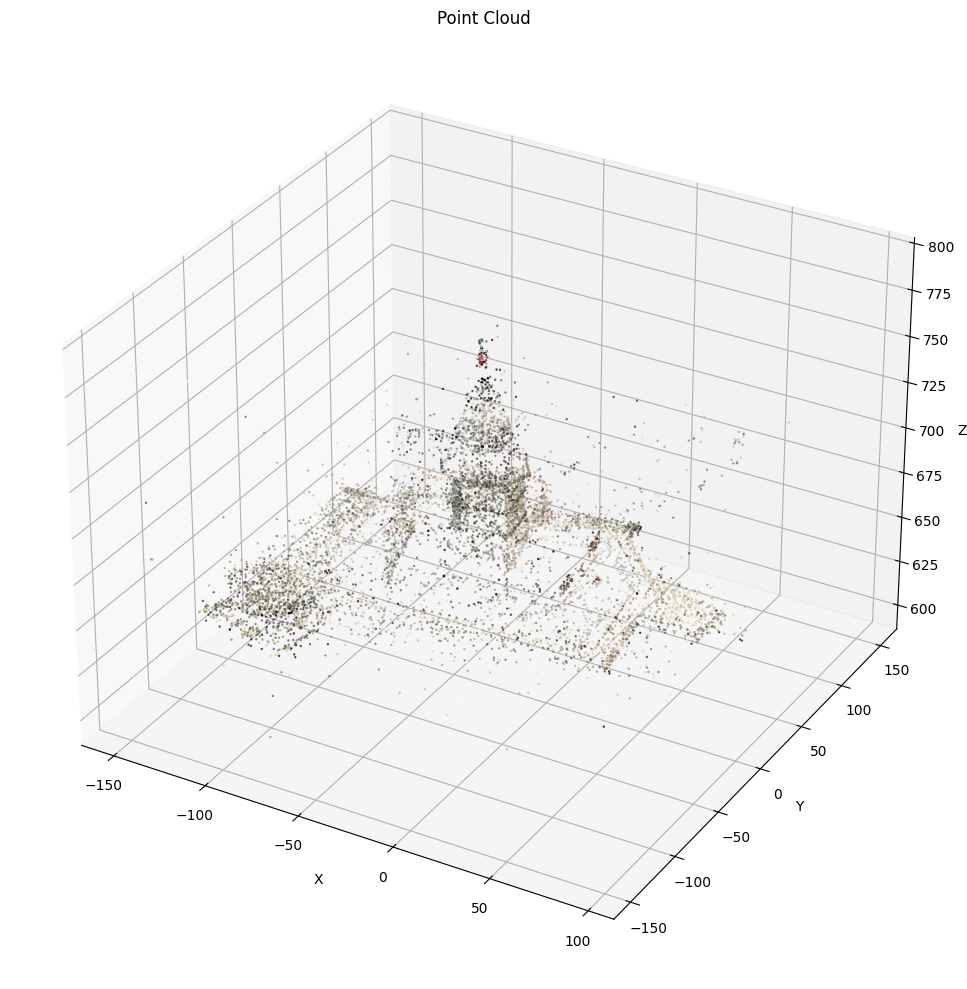

In [91]:
fig2d = plt.figure(figsize=(14, 10))
ax = fig2d.add_subplot(111, projection='3d')
ax.scatter(rotated[:, 0], rotated[:, 1], rotated[:, 2],
           c=colors/255.0, s=0.5)
ax.set_title("Point Cloud")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.tight_layout()
plt.savefig("point_cloud.png", dpi=150)
plt.show()

In [92]:
# ── 1. Extract camera centres from pose_array ─────────────────────────────────
# pose_array layout: [K.ravel (9), P1.ravel (12), P2.ravel (12), ...]
# Skip the first 9 values (intrinsic matrix) then read 12 values per camera.

K_flat_len = 9
P_len = 12

num_cameras = (len(pose_array) - K_flat_len) // P_len
camera_centers = []

for i in range(num_cameras):
    start = K_flat_len + i * P_len
    P = pose_array[start : start + P_len].reshape(3, 4)   # 3×4 projection matrix

    # Decompose P = K · [R | t]  →  R and t are the extrinsic components
    # Camera centre in world coords: C = -R^T · t
    R = P[:, :3]          # left 3×3 block (already K·R, so undo K first)
    KR = R
    Kt = P[:, 3]

    # Recover true R and t by stripping K
    K_inv = np.linalg.inv(K)
    R_true = K_inv @ KR
    t_true = K_inv @ Kt

    # Camera centre: C = -R^T · t
    C = -R_true.T @ t_true
    camera_centers.append(C)

camera_centers = np.array(camera_centers)   # shape (N, 3)

# ── 2. Apply the same rotation used on the point cloud ───────────────────────
rx, ry, rz = 230, 0, 45   # ← match your point cloud rotation angles

def Rx(a):
    a = np.radians(a)
    return np.array([[1,0,0],[0,np.cos(a),-np.sin(a)],[0,np.sin(a),np.cos(a)]])

def Ry(a):
    a = np.radians(a)
    return np.array([[np.cos(a),0,np.sin(a)],[0,1,0],[-np.sin(a),0,np.cos(a)]])

def Rz(a):
    a = np.radians(a)
    return np.array([[np.cos(a),-np.sin(a),0],[np.sin(a),np.cos(a),0],[0,0,1]])

R = Rz(rz) @ Ry(ry) @ Rx(rx)

centroid = points.mean(axis=0)  # reuse centroid from the point cloud cell
centered = camera_centers - centroid
camera_centers = (R @ centered.T).T + centroid

# Extract x/y/z AFTER rotation
xs, ys, zs = camera_centers[:, 0], camera_centers[:, 1], camera_centers[:, 2]

# ── 3. Build cone (arrow) data for camera orientations ────────────────────────
arrow_step = max(1, num_cameras // 10)
cone_x, cone_y, cone_z = [], [], []
cone_u, cone_v, cone_w = [], [], []

for i in range(0, num_cameras, arrow_step):
    start_idx = K_flat_len + i * P_len
    P = pose_array[start_idx : start_idx + P_len].reshape(3, 4)
    R_true = np.linalg.inv(K) @ P[:, :3]
    look = R_true[2]    # optical axis (row 2 of R)
    look = R @ look     # rotate the direction vector to match
    cone_x.append(xs[i]); cone_y.append(ys[i]); cone_z.append(zs[i])
    cone_u.append(look[0]); cone_v.append(look[1]); cone_w.append(look[2])

# ── 4. Plot with Plotly ───────────────────────────────────────────────────────
fig = go.Figure()

# Trajectory line
fig.add_trace(go.Scatter3d(
    x=xs, y=ys, z=zs,
    mode='lines+markers',
    line=dict(color='steelblue', width=3),
    marker=dict(size=3, color='steelblue'),
    name='Trajectory'
))

# Start / end markers
fig.add_trace(go.Scatter3d(
    x=[xs[0]], y=[ys[0]], z=[zs[0]],
    mode='markers',
    marker=dict(size=8, color='green', symbol='diamond'),
    name='Start'
))
fig.add_trace(go.Scatter3d(
    x=[xs[-1]], y=[ys[-1]], z=[zs[-1]],
    mode='markers',
    marker=dict(size=8, color='red', symbol='diamond'),
    name='End'
))

# Camera orientation cones
fig.add_trace(go.Cone(
    x=cone_x, y=cone_y, z=cone_z,
    u=cone_u, v=cone_v, w=cone_w,
    sizemode='absolute', sizeref=0.15,
    colorscale=[[0, 'orange'], [1, 'orange']],
    showscale=False,
    name='Look direction'
))

fig.update_layout(
    title=f'Camera Trajectory ({num_cameras} cameras)',
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
               aspectmode='data'),
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(x=0.01, y=0.99)
)

fig.show()
print(f"Total cameras plotted: {num_cameras}")
fig.write_html("camera_trajectory.html")



Total cameras plotted: 25


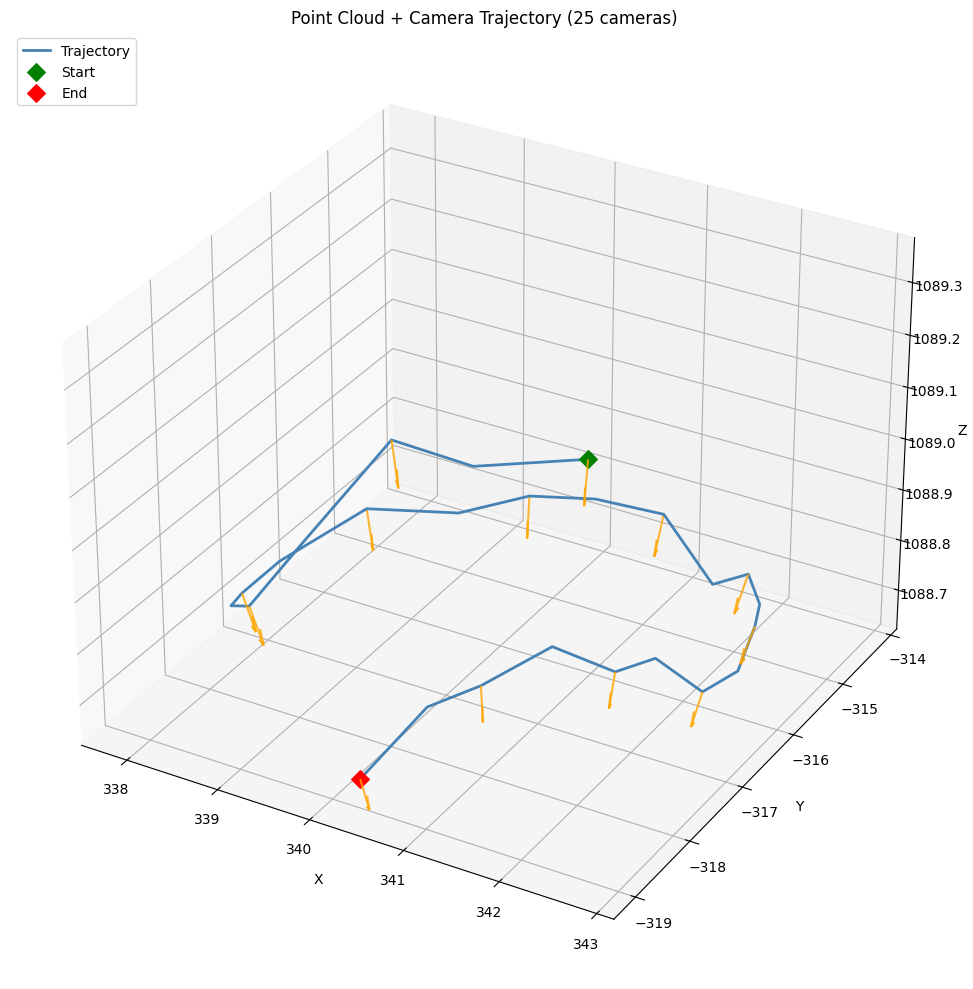

In [93]:
fig2d = plt.figure(figsize=(14, 10))
ax = fig2d.add_subplot(111, projection='3d')

# Trajectory line
ax.plot(xs, ys, zs, color='steelblue', linewidth=2, zorder=5, label='Trajectory')

# Start / end markers
ax.scatter(*camera_centers[0],  color='green', s=80, marker='D', zorder=6, label='Start')
ax.scatter(*camera_centers[-1], color='red',   s=80, marker='D', zorder=6, label='End')

# Camera orientation arrows (every arrow_step-th camera)
for i in range(len(cone_x)):
    ax.quiver(cone_x[i], cone_y[i], cone_z[i],
              cone_u[i], cone_v[i], cone_w[i],
              length=0.15, color='orange', normalize=True, alpha=0.8)

ax.set_title(f'Point Cloud + Camera Trajectory ({num_cameras} cameras)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('point_cloud_with_trajectory.png', dpi=150)
plt.show()